In [2]:
import json
import hashlib
import os
import re
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from datasets import load_dataset, get_dataset_config_names
from tqdm import tqdm
import numpy as np
import random
from collections import Counter

def set_seed(seed=42):
    """Set random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [3]:
def get_last_n_token_data(data_dir: str, section: str, idx: int, question_name: str, layer_idx: int, n: int):
    """
    Load activations and labels for a single MMLU question, but only the last token.
    Returns a single record with 'activations', 'model_answer', and 'correct_answer', or None if parsing fails.
    """
    answer_mapping = {'A': 0, 'B': 1, 'C': 2, 'D': 3}
    question_id = hashlib.md5(f"{section}_{idx}_{question_name}".encode()).hexdigest()[:12]

    activation_dir = f'{data_dir}/stage2_activations/layer_{layer_idx}/{question_id}'
    if not os.path.exists(activation_dir):
        return None
    activation_file = os.listdir(activation_dir)[0]
    path = f'{activation_dir}/{activation_file}'
    activations = torch.load(path)

    metadata_file = f'{data_dir}/stage1_responses/{question_id}.json'
    metadata = json.load(open(metadata_file))
    
    # Try to extract the answer from the model's response
    if metadata['parsed_answer'] in answer_mapping:
        model_answer = metadata['parsed_answer']
    else:
        pattern = r'\\boxed\{[^}]*\}'
        model_response = metadata["full_response"]["choices"][0]["message"]["content"]
        match = re.search(pattern, model_response)
        if match:
            boxed_content = match.group(0)
            model_answer = re.sub(r'\\boxed\{|\\text\{|\}', '', boxed_content)
        else:
            return None

    model_answer = answer_mapping[model_answer]
    correct_answer = answer_mapping[metadata['correct_answer']]
    
    # Get only the last token
    n = min(n, len(activations))
    last_n_token_activations = activations[-n:]  # Last n tokens
    output = []
    for i in range(n):
        output.append({
            'activations': last_n_token_activations[i],
            'model_answer': model_answer,
            'correct_answer': correct_answer,
            'category': section
        })
    return output
class LastTokenDataset(Dataset):
    """Dataset for last token activations."""
    def __init__(self, ds: list):
        self.ds = ds

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        activation = self.ds[idx]['activations']
        label = torch.tensor(self.ds[idx]['label'], dtype=torch.long)
        return activation, label

def get_datasets(data_dir: str, layer_idx: int, label_type: str = 'model_answer', train_test_split_ratio: float = 0.8, seed: int = 42, n: int = 1):
    """Build train/test datasets for last token activations."""
    categories = get_dataset_config_names("edinburgh-dawg/mmlu-redux-2.0")
    activation_data = []
    
    print("Loading data...")
    for category in tqdm(categories):
        user = os.environ.get("USER", os.path.basename(os.path.expanduser("~")))
        cache_dir = f"/mnt/polished-lake/home/{user}/.cache/huggingface/datasets"
        os.makedirs(cache_dir, exist_ok=True)
        
        ds = load_dataset('edinburgh-dawg/mmlu-redux-2.0', category, cache_dir=cache_dir)['test']
        for i in range(len(ds)):
            question_data = get_last_n_token_data(data_dir, category, i, ds[i]['question'], layer_idx, n)
            if question_data is not None:
                activation_data.extend(question_data)
    
    # Prepare labels
    labels = []
    for item in activation_data:
        if label_type == 'model_answer':
            item['label'] = item['model_answer']
        elif label_type == 'correct_answer':
            item['label'] = item['correct_answer']
        elif label_type == 'model_correct':
            item['label'] = item['model_answer'] == item['correct_answer']
        labels.append(item['label'])
    
    # Print label distribution
    label_counts = Counter(labels)
    total = len(labels)
    print(f"\nLabel distribution ({label_type}): {dict(label_counts)}")
    print(f"Total samples: {total}\n")
    
    # Stratified split
    train_data, test_data = train_test_split(
        activation_data, 
        test_size=1-train_test_split_ratio, 
        stratify=labels,
        random_state=seed
    )
    
    train_dataset = LastTokenDataset(train_data)
    test_dataset = LastTokenDataset(test_data)
    return train_dataset, test_dataset

In [4]:
def load_probe(model_dir: str):
    """Load the probe model."""
    model = torch.load(model_dir)
    return model

def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for activations, labels in tqdm(dataloader, desc="Training"):
        activations = activations.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(activations)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    avg_loss = total_loss / len(dataloader)
    return avg_loss, accuracy

def evaluate(model, dataloader, criterion, device):
    """Evaluate the model."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for activations, labels in tqdm(dataloader, desc="Evaluating"):
            activations = activations.to(device)
            labels = labels.to(device)
            
            outputs = model(activations)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    avg_loss = total_loss / len(dataloader)
    return avg_loss, accuracy


In [5]:
user = os.environ.get("USER", os.path.basename(os.path.expanduser("~")))
# Hardcoded configuration
data_dir = '/mnt/polished-lake/data/mmlu_activations'
layer_idx = 60
label_type = 'model_answer'  # or 'correct_answer' or 'model_correct'
batch_size = 32
learning_rate = 0.001
num_epochs = 20
train_test_split_ratio = 0.8
seed = 42
last_n_tokens = 1
probe_path = f'/mnt/polished-lake/home/{user}/disentangling-computation-from-cot/probing/results/layerwise/models/layerwise_layer60.pt'
set_seed(seed)

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# Testing including last pos

In [6]:
# Load datasets
final_accs = {}
for n in [1, 5, 10, 25, 50, 100, 200, 500, 1000, 2000]:
    train_dataset, test_dataset = get_datasets(
        data_dir, layer_idx, label_type, train_test_split_ratio, seed, n
    )

    print(f"Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Determine number of classes
    if label_type in ['model_answer', 'correct_answer']:
        num_classes = 4  # A, B, C, D
    elif label_type == 'model_correct':
        num_classes = 2  # Correct/Incorrect
    else:
        raise ValueError(f"Unknown label_type: {label_type}")

    # Get input dimension from first sample
    sample_activation, _ = train_dataset[0]
    input_dim = len(sample_activation)


    model = torch.nn.Linear(input_dim, num_classes, dtype=torch.bfloat16).to(device)

    correct = 0
    total = 0
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    for epoch in range(num_epochs):
        for batch in train_loader:
            activations, labels = batch
            activations = activations.to(device)
            labels = labels.to(device)
            outputs = model(activations)
            loss = loss_fn(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        with torch.no_grad():
            for batch in test_loader:
                activations, labels = batch
                activations = activations.to(device)
                labels = labels.to(device)
                outputs = model(activations)
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        accuracy = 100 * correct / total
        print(f"Epoch {epoch+1}/{num_epochs} - Accuracy: {accuracy}%")
    del model, train_loader, test_loader, train_dataset, test_dataset
    final_accs[n] = accuracy
    print()
    print()


for n, acc in final_accs.items():
    print(f"N: {n} - Accuracy: {acc}%")


Loading data...


  2%|▏         | 1/57 [00:06<05:52,  6.30s/it]


KeyboardInterrupt: 

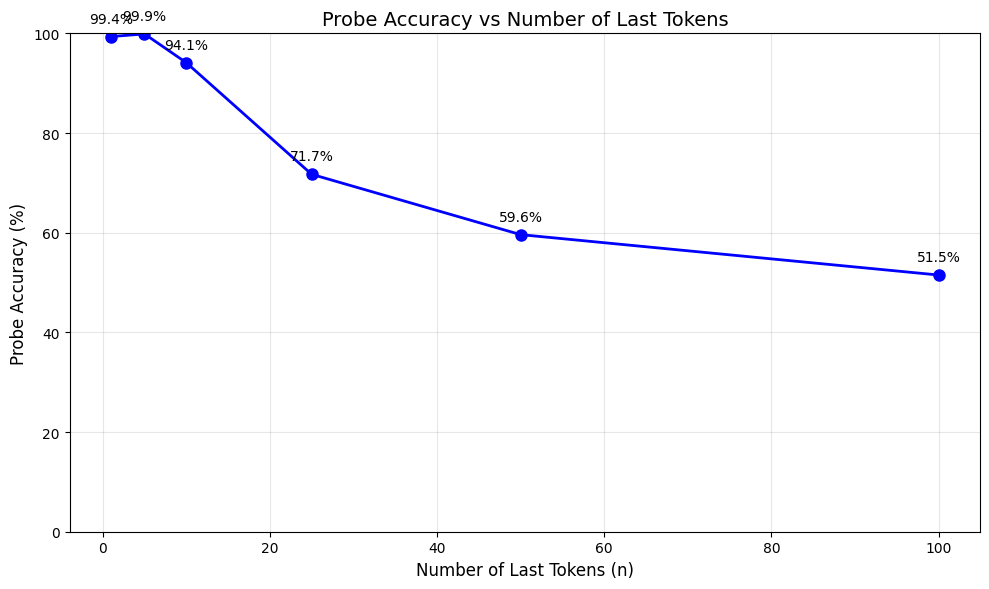

Summary:
Best accuracy: 99.89% (n=5)
Worst accuracy: 51.51% (n=100)
Accuracy range: 48.38 percentage points


In [ ]:
import matplotlib.pyplot as plt

# Plot the results
n_values = list(final_accs.keys())
accuracies = list(final_accs.values())

plt.figure(figsize=(10, 6))
plt.plot(n_values, accuracies, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Last N Tokens Included in Probe Dataset (n)', fontsize=12)
plt.ylabel('Probe Accuracy (%)', fontsize=12)
plt.title('Probe Accuracy vs Range of Last N Tokens Included', fontsize=14)
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)

# Add value labels on points
for n, acc in zip(n_values, accuracies):
    plt.annotate(f'{acc:.1f}%', (n, acc), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Print summary
print("Summary:")
print(f"Best accuracy: {max(accuracies):.2f}% (n={n_values[accuracies.index(max(accuracies))]})")
print(f"Worst accuracy: {min(accuracies):.2f}% (n={n_values[accuracies.index(min(accuracies))]})")
print(f"Accuracy range: {max(accuracies) - min(accuracies):.2f} percentage points")


In [ ]:
def get_chunked_token_data(data_dir: str, section: str, idx: int, question_name: str, layer_idx: int, 
                          distance_from_end: int, chunk_size: int = 30):
    """
    Load activations for a specific chunk of tokens.
    
    Args:
        distance_from_end: How many tokens from the end to start the chunk (0 = last chunk, 30 = chunk starting 30 tokens from end)
        chunk_size: Size of the chunk in tokens
    """
    answer_mapping = {'A': 0, 'B': 1, 'C': 2, 'D': 3}
    question_id = hashlib.md5(f"{section}_{idx}_{question_name}".encode()).hexdigest()[:12]

    activation_dir = f'{data_dir}/stage2_activations/layer_{layer_idx}/{question_id}'
    if not os.path.exists(activation_dir):
        return None
    activation_file = os.listdir(activation_dir)[0]
    path = f'{activation_dir}/{activation_file}'
    activations = torch.load(path)

    metadata_file = f'{data_dir}/stage1_responses/{question_id}.json'
    metadata = json.load(open(metadata_file))
    
    if metadata['parsed_answer'] in answer_mapping:
        model_answer = metadata['parsed_answer']
    else:
        pattern = r'\\boxed\{[^}]*\}'
        model_response = metadata["full_response"]["choices"][0]["message"]["content"]
        match = re.search(pattern, model_response)
        if match:
            boxed_content = match.group(0)
            model_answer = re.sub(r'\\boxed\{|\\text\{|\}', '', boxed_content)
        else:
            return None

    model_answer = answer_mapping[model_answer]
    correct_answer = answer_mapping[metadata['correct_answer']]
    
    # Get the specific chunk
    seq_len = len(activations)
    start_idx = seq_len - distance_from_end - chunk_size
    end_idx = seq_len - distance_from_end
    
    if start_idx < 0:
        return None
    
    chunk_activations = activations[start_idx:end_idx]
    chunk_activations = chunk_activations.flatten()
    
    return {
        'activations': chunk_activations,
        'model_answer': model_answer,
        'correct_answer': correct_answer,
        'category': section
    }


In [ ]:
class ChunkedDataset(Dataset):
    """Dataset for chunked activations."""
    def __init__(self, ds: list):
        self.ds = ds

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        activation = self.ds[idx]['activations']
        label = torch.tensor(self.ds[idx]['label'], dtype=torch.long)
        return activation, label

def get_chunked_datasets(data_dir: str, layer_idx: int, distance_from_end: int, label_type: str = 'model_answer', 
                        train_test_split_ratio: float = 0.8, seed: int = 42, chunk_size: int = 30):
    """Build train/test datasets for a specific chunk."""
    categories = get_dataset_config_names("edinburgh-dawg/mmlu-redux-2.0")
    activation_data = []
    
    print(f"Loading data for chunk {distance_from_end} tokens from end (size {chunk_size})...")
    for category in tqdm(categories):
        user = os.environ.get("USER", os.path.basename(os.path.expanduser("~")))
        cache_dir = f"/mnt/polished-lake/home/{user}/.cache/huggingface/datasets"
        os.makedirs(cache_dir, exist_ok=True)
        
        ds = load_dataset('edinburgh-dawg/mmlu-redux-2.0', category, cache_dir=cache_dir)['test']
        for i in range(len(ds)):
            question_data = get_chunked_token_data(data_dir, category, i, ds[i]['question'], layer_idx, distance_from_end, chunk_size)
            if question_data is not None:
                activation_data.append(question_data)
    
    # Prepare labels
    labels = []
    for item in activation_data:
        if label_type == 'model_answer':
            item['label'] = item['model_answer']
        elif label_type == 'correct_answer':
            item['label'] = item['correct_answer']
        elif label_type == 'model_correct':
            item['label'] = item['model_answer'] == item['correct_answer']
        labels.append(item['label'])
    
    # Print label distribution
    label_counts = Counter(labels)
    total = len(labels)
    print(f"\nLabel distribution ({label_type}) for chunk {distance_from_end} from end: {dict(label_counts)}")
    print(f"Total samples: {total}\n")
    
    # Stratified split
    train_data, test_data = train_test_split(
        activation_data, 
        test_size=1-train_test_split_ratio, 
        stratify=labels,
        random_state=seed
    )
    
    train_dataset = ChunkedDataset(train_data)
    test_dataset = ChunkedDataset(test_data)
    return train_dataset, test_dataset


In [ ]:
# Chunked evaluation - last 10 chunks from the end
chunk_accs = {}
for distance_from_end in [0, 30, 60, 90, 120, 150, 180, 210, 240, 270]:  # Last 10 chunks of 30 tokens each
    train_dataset, test_dataset = get_chunked_datasets(
        data_dir, layer_idx, distance_from_end, label_type, train_test_split_ratio, seed
    )

    print(f"Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Determine number of classes
    if label_type in ['model_answer', 'correct_answer']:
        num_classes = 4  # A, B, C, D
    elif label_type == 'model_correct':
        num_classes = 2  # Correct/Incorrect
    else:
        raise ValueError(f"Unknown label_type: {label_type}")

    # Get input dimension from first sample
    sample_activation, _ = train_dataset[0]
    input_dim = len(sample_activation)

    model = torch.nn.Linear(input_dim, num_classes, dtype=torch.bfloat16).to(device)

    correct = 0
    total = 0
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    for epoch in range(num_epochs):
        for batch in train_loader:
            activations, labels = batch
            activations = activations.to(device)
            labels = labels.to(device)
            outputs = model(activations)
            loss = loss_fn(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        with torch.no_grad():
            for batch in test_loader:
                activations, labels = batch
                activations = activations.to(device)
                labels = labels.to(device)
                outputs = model(activations)
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        accuracy = 100 * correct / total
        print(f"Epoch {epoch+1}/{num_epochs} - Accuracy: {accuracy}%")
    del model, train_loader, test_loader, train_dataset, test_dataset
    chunk_accs[distance_from_end] = accuracy
    print()
    print()

for distance_from_end, acc in chunk_accs.items():
    print(f"Chunk {distance_from_end} tokens from end (positions {distance_from_end} to {distance_from_end + 30} from end) - Accuracy: {acc}%")


# testing chunking

In [ ]:
def get_chunked_datasets(data_dir: str, section: str, idx: int, question_name: str, layer_idx: int, n: int):
    """
    Load activations and labels for a single MMLU question, but only the last token.
    Returns a single record with 'activations', 'model_answer', and 'correct_answer', or None if parsing fails.
    """
    answer_mapping = {'A': 0, 'B': 1, 'C': 2, 'D': 3}
    question_id = hashlib.md5(f"{section}_{idx}_{question_name}".encode()).hexdigest()[:12]

    activation_dir = f'{data_dir}/stage2_activations/layer_{layer_idx}/{question_id}'
    if not os.path.exists(activation_dir):
        return None
    activation_file = os.listdir(activation_dir)[0]
    path = f'{activation_dir}/{activation_file}'
    activations = torch.load(path)

    metadata_file = f'{data_dir}/stage1_responses/{question_id}.json'
    metadata = json.load(open(metadata_file))
    
    # Try to extract the answer from the model's response
    if metadata['parsed_answer'] in answer_mapping:
        model_answer = metadata['parsed_answer']
    else:
        pattern = r'\\boxed\{[^}]*\}'
        model_response = metadata["full_response"]["choices"][0]["message"]["content"]
        match = re.search(pattern, model_response)
        if match:
            boxed_content = match.group(0)
            model_answer = re.sub(r'\\boxed\{|\\text\{|\}', '', boxed_content)
        else:
            return None

    model_answer = answer_mapping[model_answer]
    correct_answer = answer_mapping[metadata['correct_answer']]
    
    # Get only the last token
    n = min(n, len(activations))
    last_n_token_activations = activations[-n:]  # Last n tokens
    output = []
    for i in range(n):
        output.append({
            'activations': last_n_token_activations[i],
            'model_answer': model_answer,
            'correct_answer': correct_answer,
            'category': section
        })
    return output
class LastTokenDataset(Dataset):
    """Dataset for last token activations."""
    def __init__(self, ds: list):
        self.ds = ds

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        activation = self.ds[idx]['activations']
        label = torch.tensor(self.ds[idx]['label'], dtype=torch.long)
        return activation, label

def get_datasets(data_dir: str, layer_idx: int, label_type: str = 'model_answer', train_test_split_ratio: float = 0.8, seed: int = 42, n: int = 1):
    """Build train/test datasets for last token activations."""
    categories = get_dataset_config_names("edinburgh-dawg/mmlu-redux-2.0")
    activation_data = []
    
    print("Loading data...")
    for category in tqdm(categories):
        user = os.environ.get("USER", os.path.basename(os.path.expanduser("~")))
        cache_dir = f"/mnt/polished-lake/home/{user}/.cache/huggingface/datasets"
        os.makedirs(cache_dir, exist_ok=True)
        
        ds = load_dataset('edinburgh-dawg/mmlu-redux-2.0', category, cache_dir=cache_dir)['test']
        for i in range(len(ds)):
            question_data = get_last_n_token_data(data_dir, category, i, ds[i]['question'], layer_idx, n)
            if question_data is not None:
                activation_data.extend(question_data)
    
    # Prepare labels
    labels = []
    for item in activation_data:
        if label_type == 'model_answer':
            item['label'] = item['model_answer']
        elif label_type == 'correct_answer':
            item['label'] = item['correct_answer']
        elif label_type == 'model_correct':
            item['label'] = item['model_answer'] == item['correct_answer']
        labels.append(item['label'])
    
    # Print label distribution
    label_counts = Counter(labels)
    total = len(labels)
    print(f"\nLabel distribution ({label_type}): {dict(label_counts)}")
    print(f"Total samples: {total}\n")
    
    # Stratified split
    train_data, test_data = train_test_split(
        activation_data, 
        test_size=1-train_test_split_ratio, 
        stratify=labels,
        random_state=seed
    )
    
    train_dataset = LastTokenDataset(train_data)
    test_dataset = LastTokenDataset(test_data)
    return train_dataset, test_dataset

In [17]:
# Chunked evaluation - same logic as the last position evaluation
chunk_accs = {}
for chunk_idx in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:  # Test first 10 chunks
    train_dataset, test_dataset = get_chunked_datasets(
        data_dir, layer_idx, chunk_idx, label_type, train_test_split_ratio, seed
    )

    print(f"Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Determine number of classes
    if label_type in ['model_answer', 'correct_answer']:
        num_classes = 4  # A, B, C, D
    elif label_type == 'model_correct':
        num_classes = 2  # Correct/Incorrect
    else:
        raise ValueError(f"Unknown label_type: {label_type}")

    # Get input dimension from first sample
    sample_activation, _ = train_dataset[0]
    input_dim = len(sample_activation)

    model = torch.nn.Linear(input_dim, num_classes, dtype=torch.bfloat16).to(device)

    correct = 0
    total = 0
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    for epoch in range(num_epochs):
        for batch in train_loader:
            activations, labels = batch
            activations = activations.to(device)
            labels = labels.to(device)
            outputs = model(activations)
            loss = loss_fn(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        with torch.no_grad():
            for batch in test_loader:
                activations, labels = batch
                activations = activations.to(device)
                labels = labels.to(device)
                outputs = model(activations)
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        accuracy = 100 * correct / total
        print(f"Epoch {epoch+1}/{num_epochs} - Accuracy: {accuracy}%")
    del model, train_loader, test_loader, train_dataset, test_dataset
    chunk_accs[chunk_idx] = accuracy
    print()
    print()

for chunk_idx, acc in chunk_accs.items():
    print(f"Chunk {chunk_idx} (positions {chunk_idx * 30} to {(chunk_idx + 1) * 30} from end) - Accuracy: {acc}%")


Loading chunked data...


100%|██████████| 57/57 [03:23<00:00,  3.57s/it]


KeyError: 'label'

In [ ]:
import matplotlib.pyplot as plt
 
# Plot chunked results
chunk_indices = list(chunk_accs.keys())
chunk_accuracies = list(chunk_accs.values())

plt.figure(figsize=(10, 6))
plt.plot(chunk_indices, chunk_accuracies, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Chunk Index (0 = last 30 tokens, 1 = 30-60 from end, etc.)', fontsize=12)
plt.ylabel('Probe Accuracy (%)', fontsize=12)
plt.title('Probe Accuracy vs Chunk Position (30-token segments)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)

# Add value labels on points
for chunk_idx, acc in zip(chunk_indices, chunk_accuracies):
    plt.annotate(f'{acc:.1f}%', (chunk_idx, acc), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Print summary
print("Summary:")
print(f"Best accuracy: {max(chunk_accuracies):.2f}% (chunk {chunk_indices[chunk_accuracies.index(max(chunk_accuracies))]})")
print(f"Worst accuracy: {min(chunk_accuracies):.2f}% (chunk {chunk_indices[chunk_accuracies.index(min(chunk_accuracies))]})")
print(f"Accuracy range: {max(chunk_accuracies) - min(chunk_accuracies):.2f} percentage points")


NameError: name 'plt' is not defined

In [ ]:
# Chunked evaluation - last 10 chunks from the end
chunk_accs = {}
for chunk_idx in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:  # Last 10 chunks from end
    train_dataset, test_dataset = get_chunked_datasets(
        data_dir, layer_idx, chunk_idx, label_type, train_test_split_ratio, seed
    )

    print(f"Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Determine number of classes
    if label_type in ['model_answer', 'correct_answer']:
        num_classes = 4  # A, B, C, D
    elif label_type == 'model_correct':
        num_classes = 2  # Correct/Incorrect
    else:
        raise ValueError(f"Unknown label_type: {label_type}")

    # Get input dimension from first sample
    sample_activation, _ = train_dataset[0]
    input_dim = len(sample_activation)

    model = torch.nn.Linear(input_dim, num_classes, dtype=torch.bfloat16).to(device)

    correct = 0
    total = 0
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    for epoch in range(num_epochs):
        for batch in train_loader:
            activations, labels = batch
            activations = activations.to(device)
            labels = labels.to(device)
            outputs = model(activations)
            loss = loss_fn(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        with torch.no_grad():
            for batch in test_loader:
                activations, labels = batch
                activations = activations.to(device)
                labels = labels.to(device)
                outputs = model(activations)
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        accuracy = 100 * correct / total
        print(f"Epoch {epoch+1}/{num_epochs} - Accuracy: {accuracy}%")
    del model, train_loader, test_loader, train_dataset, test_dataset
    chunk_accs[chunk_idx] = accuracy
    print()
    print()

for chunk_idx, acc in chunk_accs.items():
    print(f"Chunk {chunk_idx} (positions {chunk_idx * 30} to {(chunk_idx + 1) * 30} from end) - Accuracy: {acc}%")
